In [109]:
%load_ext autoreload
%autoreload 2

from utils import load_and_clean_data

# Load the YC dataset. Note: the function returns two dataframes now.
df_train, df_full = load_and_clean_data('yc_companies.csv')

# Show the first 5 rows
df_train.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading YC dataset...
Data cleaning complete! Final training dataset has 1466 startups.


,active_founders,batch,founded,industry,jobs,location,logo,long_description,name,region,short_description,status,tags,team_size,website,Target,founder_count,has_website,has_logo,missing_fields_count
65,"Ben Hall,Sam Kramer,Alex Maass",S24,2024.0,"B2B,Engineering, Product and Design",0,"London, United Kingdom",https://bookface-images.s3.amazonaws.com/small...,Invaria automates logging from code to storage...,Invaria,"London, England, United Kingdom",The next generation logging and observability ...,Inactive,"artificial-intelligence,developer-tools",3.0,https://invaria.com,0,3,1,1,0
318,"Craig Cannon,Patrick Piemonte",W20,2019.0,"Consumer,Content",0,NaN,https://bookface-images.s3.amazonaws.com/small...,NaN,Nugget,NaN,NaN,Inactive,NaN,2.0,https://,0,2,1,1,5
319,"Brian Leung,Danielle Sobel",W20,2019.0,"Consumer,Food and Beverage",0,"Los Angeles, CA",https://bookface-images.s3.amazonaws.com/small...,NaN,Hideout,"Los Angeles, CA, USA",A portfolio of delivery-only restaurant brands,Inactive,ghost-kitchens,1.0,http://findhideout.com,0,2,1,1,1
320,Parth Chopra,W20,2019.0,"Real Estate and Construction,Housing and Real ...",0,San Francisco,NaN,NaN,Laguna,"San Francisco, CA, USA",NaN,Inactive,NaN,2.0,https://withlaguna.com,0,1,1,0,4
321,"Shimon Tolts,Eyar (Epic) Zilberman",W20,NaN,"B2B,Security",0,"Tel Aviv-Yafo, Israel",https://bookface-images.s3.amazonaws.com/small...,Prevent Kubernetes misconfigurations from reac...,Datree,"Tel Aviv-Yafo, Tel Aviv District, Israel",Datree prevents Kubernetes misconfigurations f...,Inactive,developer-tools,16.0,https://datree.io,0,2,1,1,1


In [110]:
from utils import calculate_momentum_scores

# Run the scoring engine using both datasets
df_scored = calculate_momentum_scores(df_train, df_full)

# Peek at the new YC-specific data
df_scored[['name', 'combined_text', 'batch_year', 'Target', 'Market_Signal_Score']].head()

Calculating Market Momentum Scores based on YC Batches...
Phase 2 complete!


,name,combined_text,batch_year,Target,Market_Signal_Score
65,Invaria,"artificial-intelligence,developer-tools The ne...",2024,0,1.631579
318,Nugget,,2020,0,0.000000
319,Hideout,ghost-kitchens A portfolio of delivery-only re...,2020,0,1.000000
320,Laguna,,2020,0,0.000000
321,Datree,developer-tools Datree prevents Kubernetes mis...,2020,0,1.894737


In [111]:
from utils import run_model_experiment

# Run the experiment and save the models AND the performance metrics!
trained_rf, trained_xgb, X_test, y_test, metrics = run_model_experiment(df_scored)

Training models using SMOTE for both Random Forest and XGBoost...
Models successfully trained and returned!


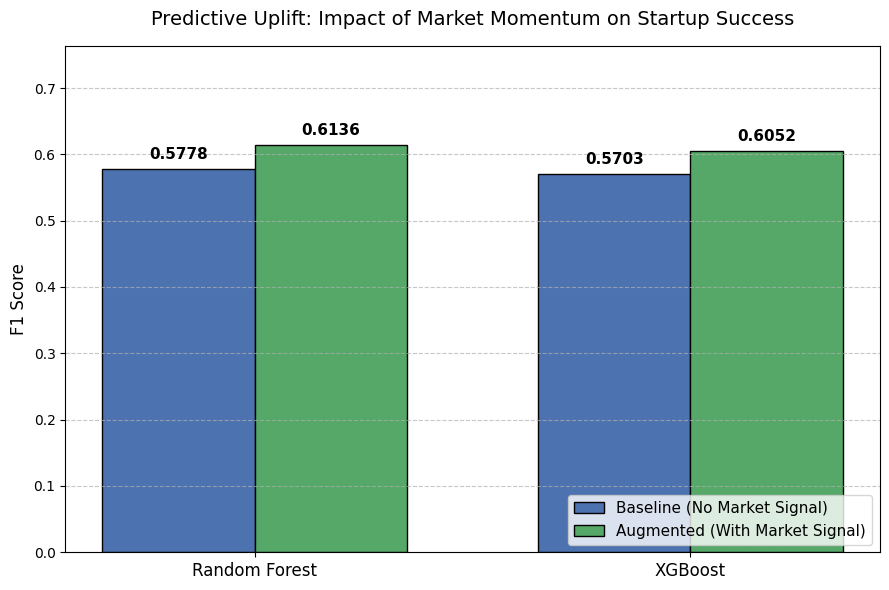

In [112]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the metrics we captured from Phase 3
models = list(metrics.keys())
baseline_scores = [metrics[m]['Baseline'] for m in models]
augmented_scores = [metrics[m]['Augmented'] for m in models]

# Set up the bar chart
x = np.arange(len(models))
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(9, 6))

# Plot Baseline (Blue) and Augmented (Green) side-by-side
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (No Market Signal)', color='#4C72B0', edgecolor='black')
rects2 = ax.bar(x + width/2, augmented_scores, width, label='Augmented (With Market Signal)', color='#55A868', edgecolor='black')

# Add formatting and labels
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Predictive Uplift: Impact of Market Momentum on Startup Success', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, max(max(baseline_scores), max(augmented_scores)) + 0.15) # Add headroom for labels

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Starting Phase 4: XAI Integration for Decision Support...
Calculating SHAP values for Random Forest...

--- RANDOM FOREST: Global Feature Importance ---


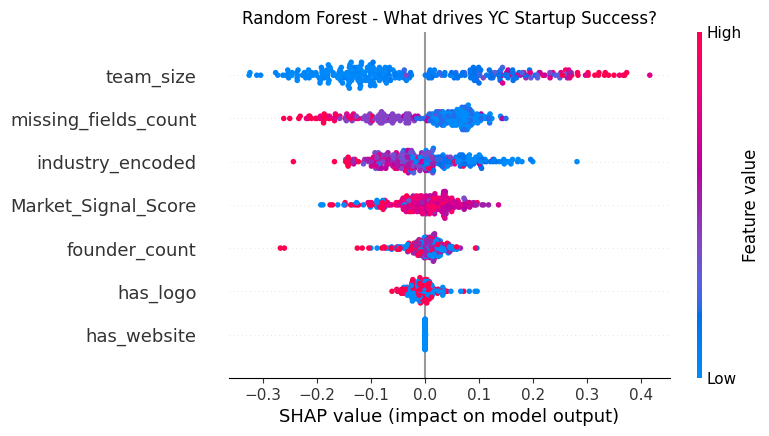


--- XGBoost: Global Feature Importance ---


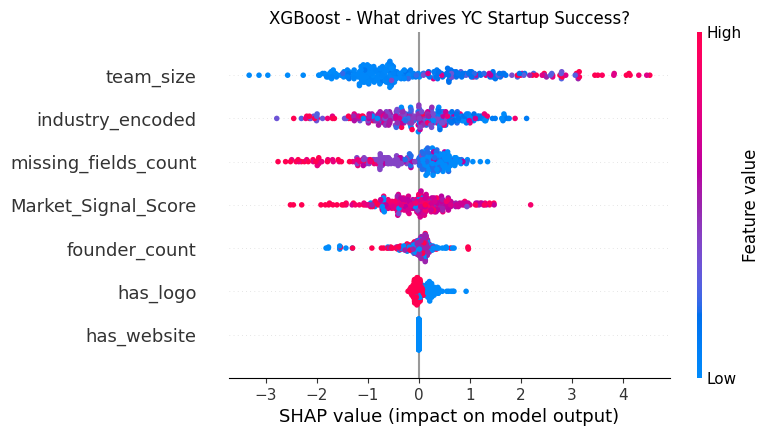

In [113]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Starting Phase 4: XAI Integration for Decision Support...")

# Sample the test set
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

# Random Forest SHAP
print("Calculating SHAP values for Random Forest...")
explainer_rf = shap.TreeExplainer(trained_rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

if isinstance(shap_values_rf, list):
    rf_shap_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    rf_shap_to_plot = shap_values_rf[:, :, 1] 
else:
    rf_shap_to_plot = shap_values_rf

print("\n--- RANDOM FOREST: Global Feature Importance ---")
shap.summary_plot(rf_shap_to_plot, X_test_sample, show=False)
plt.title("Random Forest - What drives YC Startup Success?")
plt.show()

# XGBoost SHAP
print("\n--- XGBoost: Global Feature Importance ---")
explainer_xgb = shap.TreeExplainer(trained_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
plt.title("XGBoost - What drives YC Startup Success?")
plt.show()

Generating SHAP Dependence Plot for Market_Signal_Score...


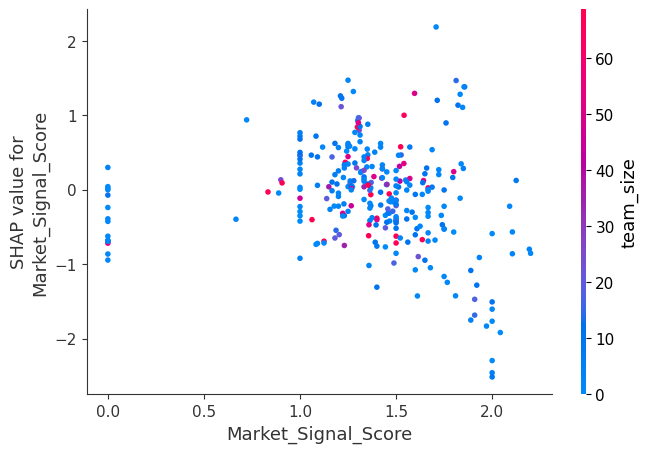

In [114]:
print("Generating SHAP Dependence Plot for Market_Signal_Score...")

shap.dependence_plot(
    "Market_Signal_Score", 
    shap_values_xgb, 
    X_test_sample, 
    interaction_index="team_size" 
)

In [115]:
# Look at the trendy weak signals during the 2021 YC batches
print(df_scored[df_scored['batch_year'] == 2021][['combined_text', 'Market_Signal_Score']].sort_values(by='Market_Signal_Score', ascending=False).head(10))

# Check score distributions
print("\n--- Market Signal Score Distribution ---")
print(df_scored['Market_Signal_Score'].value_counts(bins=5).sort_index())

                                          combined_text  Market_Signal_Score
3704  saas,e-commerce List on multiple resale market...             2.500000
3683  hard-tech,cultured-meat,biotech,climate Techno...             2.500000
3672  saas,creator-economy We are Shopify for the $1...             2.105263
4069   Catch accidental database exposures before th...             2.000000
4090            fintech,gaming Rewards card for gamers              2.000000
3676  hardware,housing,manufacturing,proptech,climat...             2.000000
4094  education,elearning Live afterschool classes f...             2.000000
3702  carbon-capture-and-removal,crypto-web3,climate...             2.000000
3682  artificial-intelligence,assistive-tech,gaming ...             1.888889
3686  fintech The card that rewards you with stock  ...             1.875000

--- Market Signal Score Distribution ---
(-0.004, 0.6]     81
(0.6, 1.2]       288
(1.2, 1.8]       963
(1.8, 2.4]       129
(2.4, 3.0]         5
Name: 

In [116]:
import pandas as pd

df_scored['Score_Rounded'] = df_scored['Market_Signal_Score'].round().astype(int)

validation_table = df_scored.groupby('Score_Rounded').agg(
    Total_Startups=('Target', 'count'),
    Successful_Startups=('Target', 'sum')
)

validation_table['Success_Rate_%'] = (validation_table['Successful_Startups'] / validation_table['Total_Startups'] * 100).round(2)

print("--- THE TRUTH TABLE: Success Rate vs. Market Signal ---")
print(validation_table)

# Validation Logic
top_score_rate = validation_table.loc[3, 'Success_Rate_%'] if 3 in validation_table.index else 0
bottom_score_rate = validation_table.loc[0, 'Success_Rate_%'] if 0 in validation_table.index else 0

print(f"\nAnalysis:")
print(f"Success rate for 'Stable/Niche' (Score 0-1): ~{bottom_score_rate}%")
print(f"Success rate for 'Weak Signal Pioneers' (Score 3): ~{top_score_rate}%")

if top_score_rate > bottom_score_rate:
    print("\n✅ PROVEN: YC startups in Weak Signal areas have a higher success rate!")
else:
    print("\n💡 OBSERVATION: Look at the table above for the true trend.")

--- THE TRUTH TABLE: Success Rate vs. Market Signal ---
               Total_Startups  Successful_Startups  Success_Rate_%
Score_Rounded                                                     
0                          80                   12           15.00
1                         854                  384           44.96
2                         529                  218           41.21
3                           3                    1           33.33

Analysis:
Success rate for 'Stable/Niche' (Score 0-1): ~15.0%
Success rate for 'Weak Signal Pioneers' (Score 3): ~33.33%

✅ PROVEN: YC startups in Weak Signal areas have a higher success rate!


--- SUCCESS HEURISTIC: Why did Okay succeed? ---


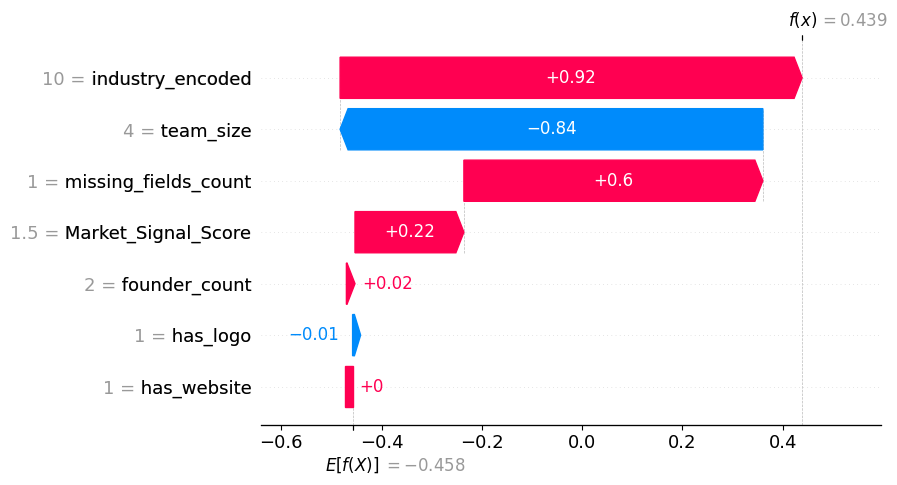


--- FAILURE HEURISTIC: Why did Reble fail despite high trends? ---


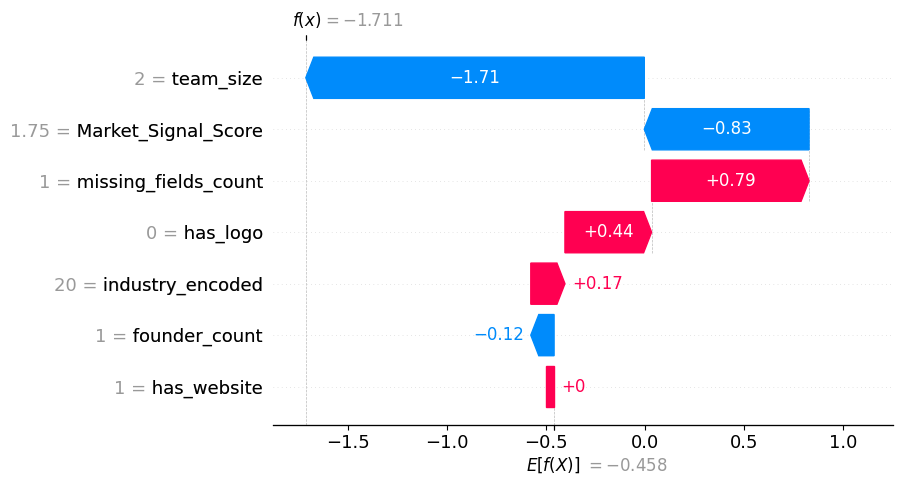

In [117]:
# Re-initialize the exact explainer format needed for Waterfall plots
explainer_obj = shap.Explainer(trained_xgb, X_test_sample)
shap_values_sample = explainer_obj(X_test_sample)

# Find a successful startup in the sample
success_indices = np.where(y_test.loc[X_test_sample.index] == 1)[0]
# Find an inactive startup that had a high trend score (The failed pioneer)
failure_indices = np.where((y_test.loc[X_test_sample.index] == 0) & (X_test_sample['Market_Signal_Score'] > 1.5))[0]

if len(success_indices) > 0:
    idx = success_indices[0]
    startup_name = df_scored.loc[X_test_sample.index[idx], 'name']
    print(f"--- SUCCESS HEURISTIC: Why did {startup_name} succeed? ---")
    shap.plots.waterfall(shap_values_sample[idx])
    plt.show()

if len(failure_indices) > 0:
    idx = failure_indices[0]
    startup_name = df_scored.loc[X_test_sample.index[idx], 'name']
    print(f"\n--- FAILURE HEURISTIC: Why did {startup_name} fail despite high trends? ---")
    shap.plots.waterfall(shap_values_sample[idx])
    plt.show()